In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('parkinsons.csv')
df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [2]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [3]:
df.tail()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306
194,phon_R01_S50_6,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,...,0.03078,0.04398,21.209,0,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569


In [14]:
df.columns

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='str')

In [12]:
print('Number of Features In Dataset :', df.shape[1])
print('Number of Instances In Dataset : ', df.shape[0])

Number of Features In Dataset : 23
Number of Instances In Dataset :  195


In [4]:
#Drop the 'name' column as it's an identifier, not a feature
if 'name' in df.columns:
    df = df.drop(['name'], axis=1)

In [5]:
df

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


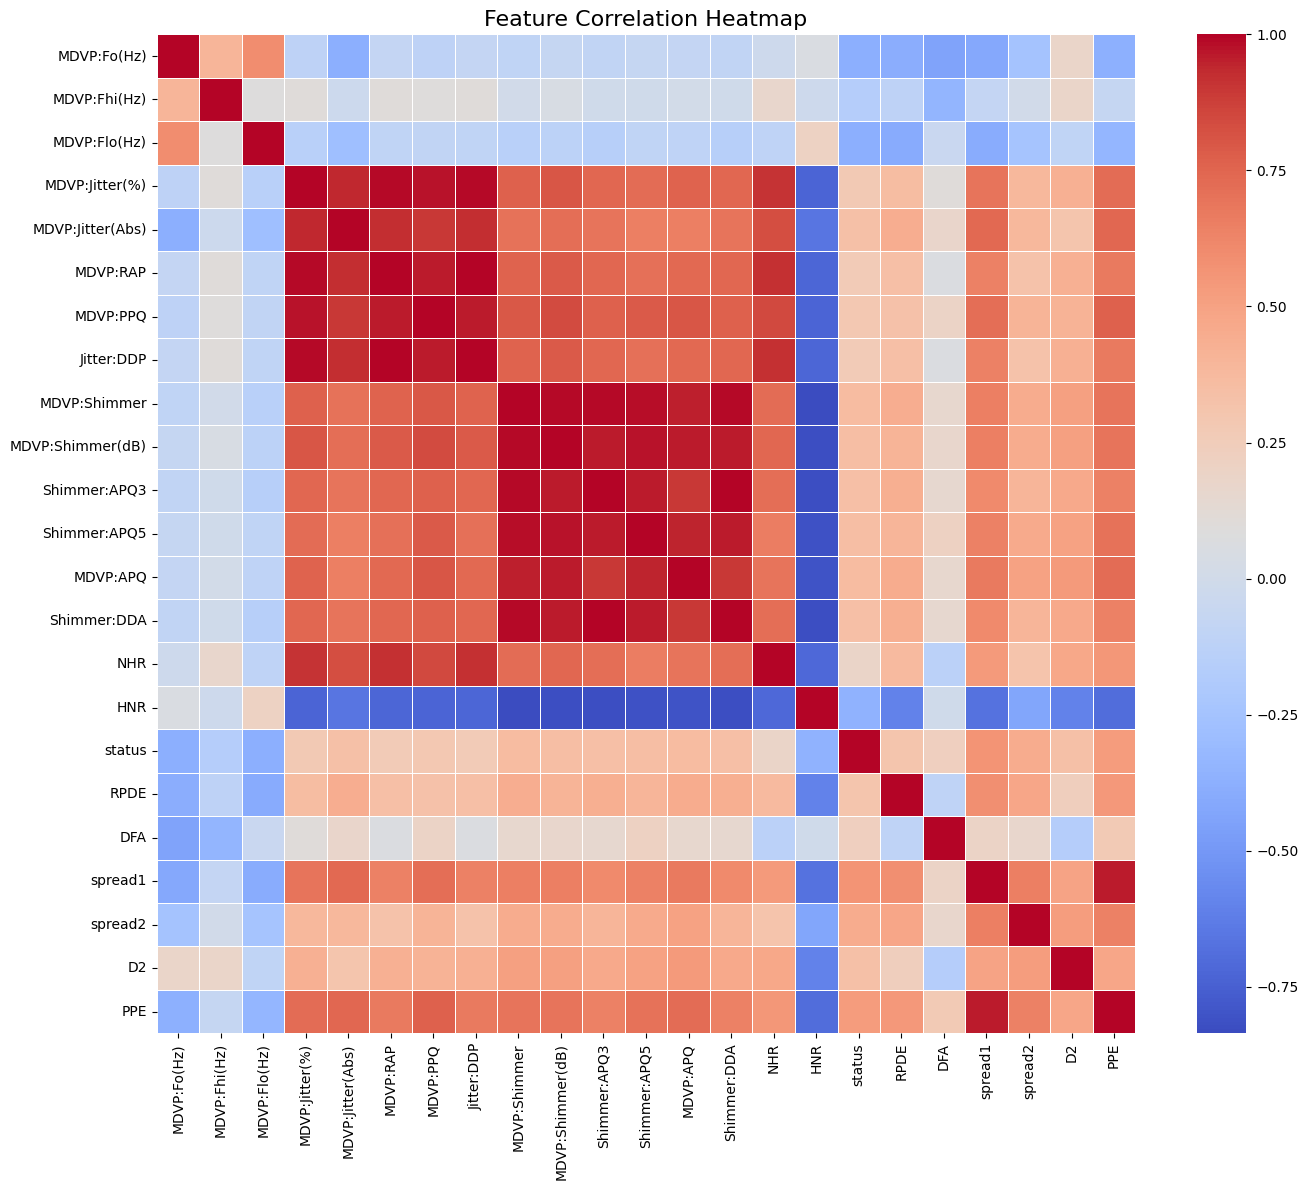

In [ ]:
# Correlation map to visualize the relationships between features

fig, ax = plt.subplots(figsize=(14, 12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()

This colorful grid shows how every single feature in your dataset is related to every other feature (including the `status`)

**Red** means strong positive correlation (as one goes up, the other goes up). **Blue** means strong negative correlation (as one goes up, the other goes down)

* Some *Jitter* and *Shimmer* features are completely red with each other, meaning they basically carry the exact same information.
* If you look closely at the column/row for status, you can see which features are most *red* or *blue* compared to it. Those are your VIP features!

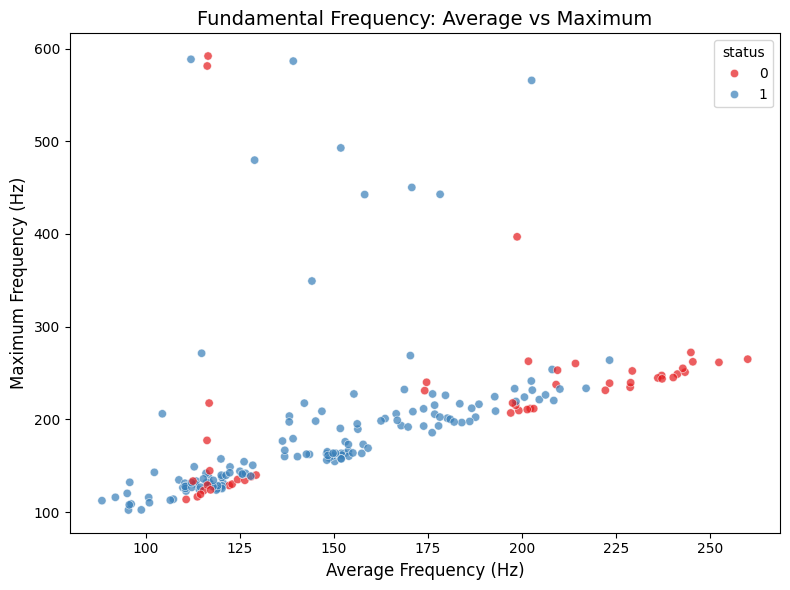

In [ ]:
# Scatter plot of Average Frequency vs Maximum Frequency colored by status (Parkinson's disease or not)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='MDVP:Fo(Hz)', y='MDVP:Fhi(Hz)', hue='status', data=df, alpha=0.7, palette='Set1', ax=ax)
ax.set_title('Fundamental Frequency: Average vs Maximum', fontsize=14)
ax.set_xlabel('Average Frequency (Hz)', fontsize=12)
ax.set_ylabel('Maximum Frequency (Hz)', fontsize=12)
plt.tight_layout()

From above graph we can conclude that most cases of Parkinson disease is concentrated in the range of:

* 225 $\leq$ Average Pitch `MDVP Fo` $\leq$ 250 and 200 $\leq$ Max Pitch `MDVP Fhi` $\leq$ 300
* 110 $\leq$ Average Pitch `MDVP Fo` $\leq$ 130 and 100 $\leq$ Max Pitch `MDVP Fhi` $\leq$ 200

We can later use this in **Decision Tree** later and will verify this observation.

In [ ]:
# Using logistic regression to predict the status of Parkinson's disease based on the features in the dataset.
X = df.drop(['status'],axis = 1)
y = df['status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state = 42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8974

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



In [ ]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9231

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39



Notice how we didn't use `StandardScaler` this time? That is because Decision Trees are absolutely magnificent in their simplicity: they don't care about the scale of the data at all! Whether a number is 0.005 or 5,000, the tree just finds the perfect threshold to draw its dividing line.

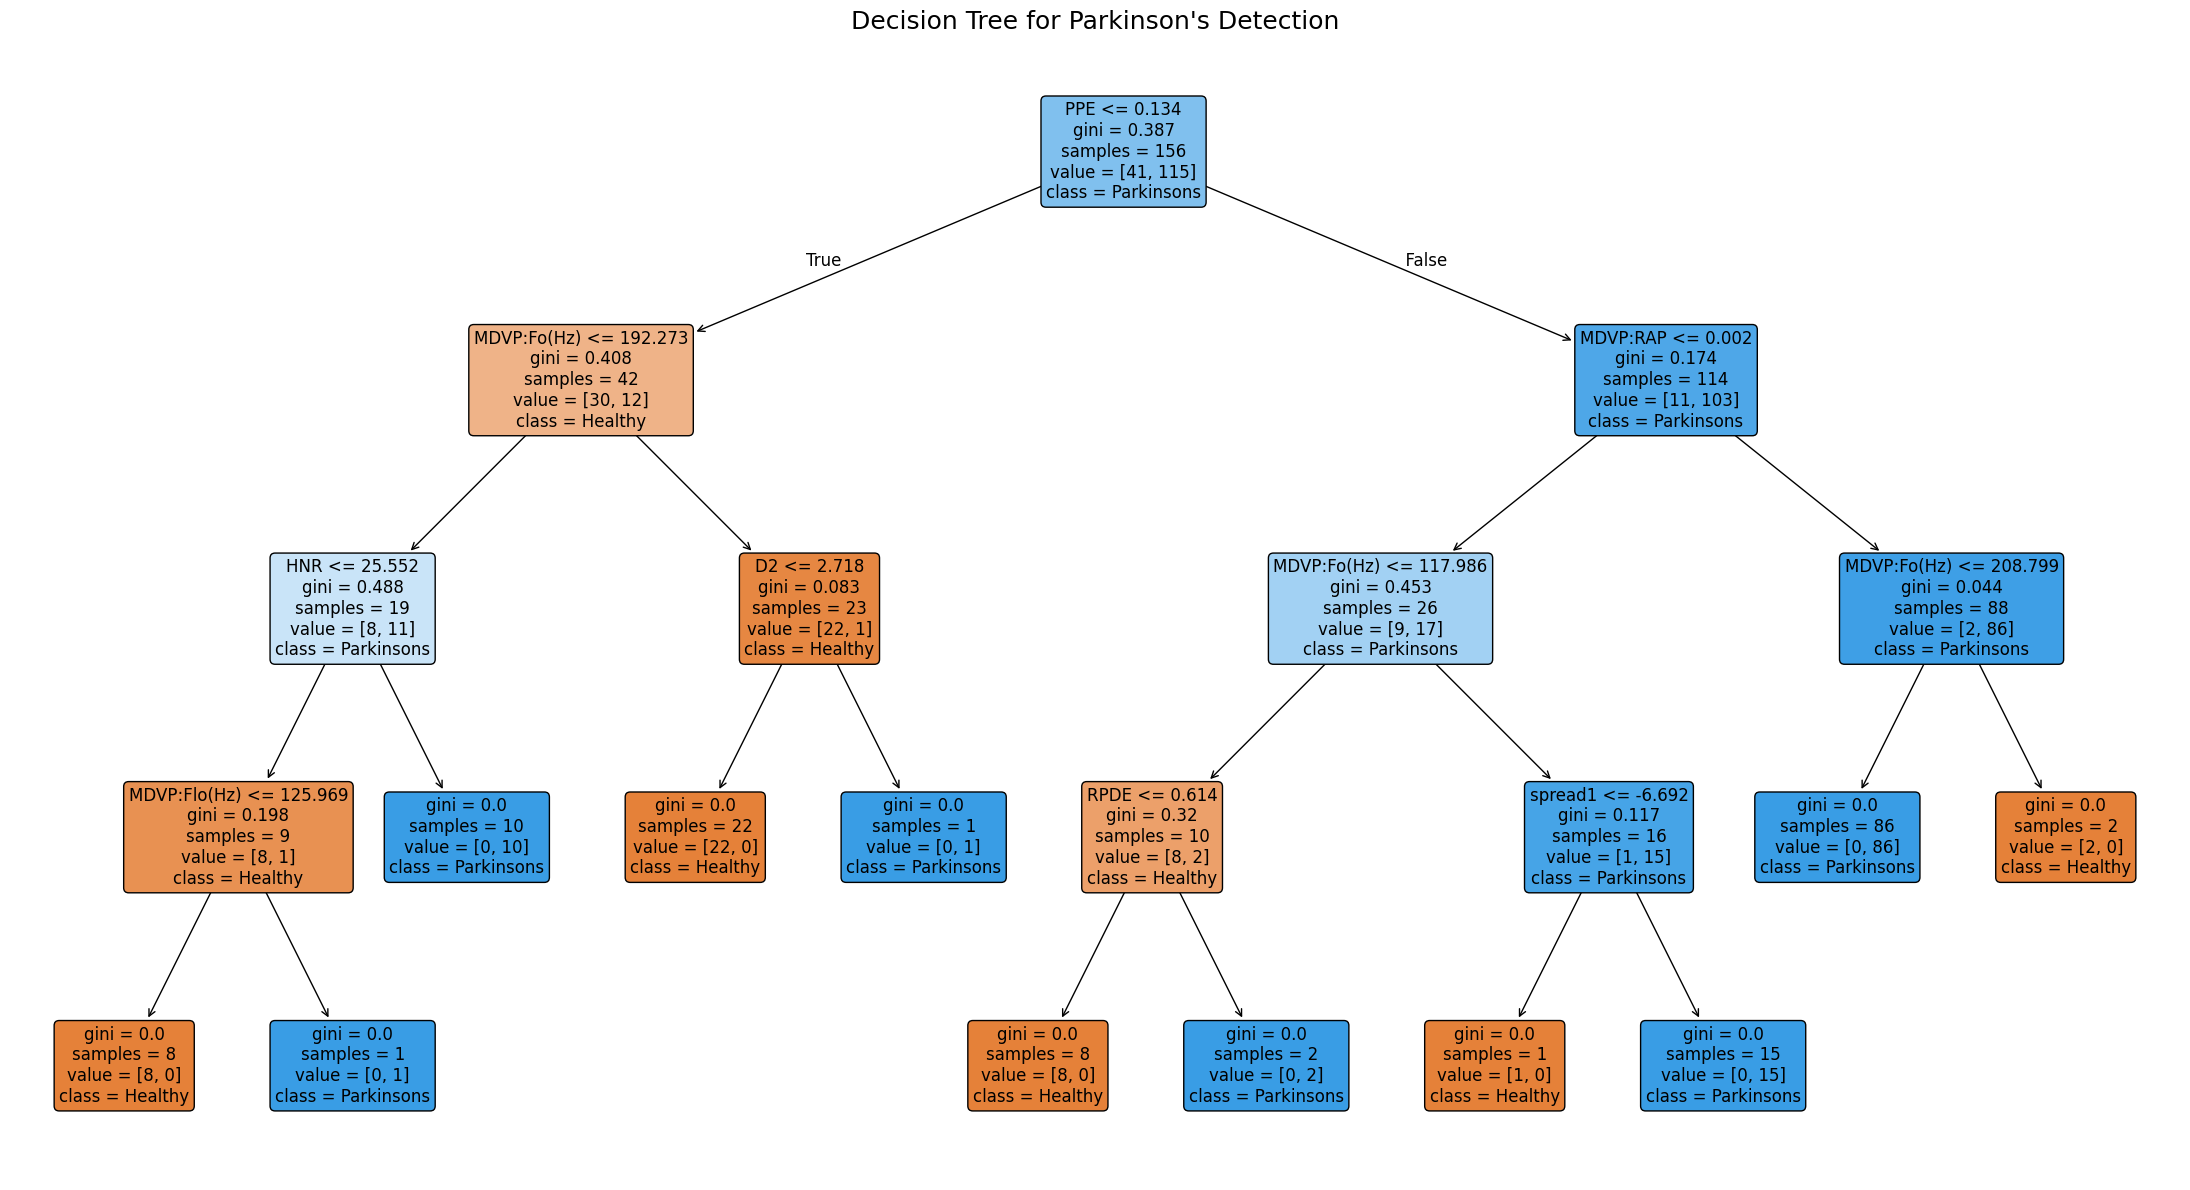

In [17]:
plt.figure(figsize=(22, 12))
plot_tree(dt_model, feature_names=X.columns, class_names=['Healthy', 'Parkinsons'], filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree for Parkinson's Detection", fontsize=18)
plt.tight_layout()

1. **The Root Node (The Top Box)**: The very first question the tree asks is: PPE $\leq$ 0.176.
   * If a patient's `PPE` is lower than 0.176, they go to the **Left** branch (mostly healthy patients—notice the blue boxes!).
   * If it's higher, they go to the **Right** branch (mostly Parkinson's patients—notice the orange/brown boxes!).

2. **The Follow-up Questions**: After the first split, the tree keeps asking more simple "Yes/No" questions using different features like `MDVP:Fhi(Hz)` (Maximum Pitch) and `MDVP:Fo(Hz)` (Average Pitch).

3. **The Leaf Nodes (The Bottom Boxes)**: Eventually, the patient lands in a box at the bottom, and the tree says: *"Okay, based on all these rules, I predict this person is Healthy (Blue) or has Parkinson's (Orange)."*

In [ ]:
# Support Vector Machines using radial basis function kernel

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8974

              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



**Accuracy: 89.74%.** The accuracy and the entire Classification Report are the exact same as what we got with our very first model, Logistic Regression!

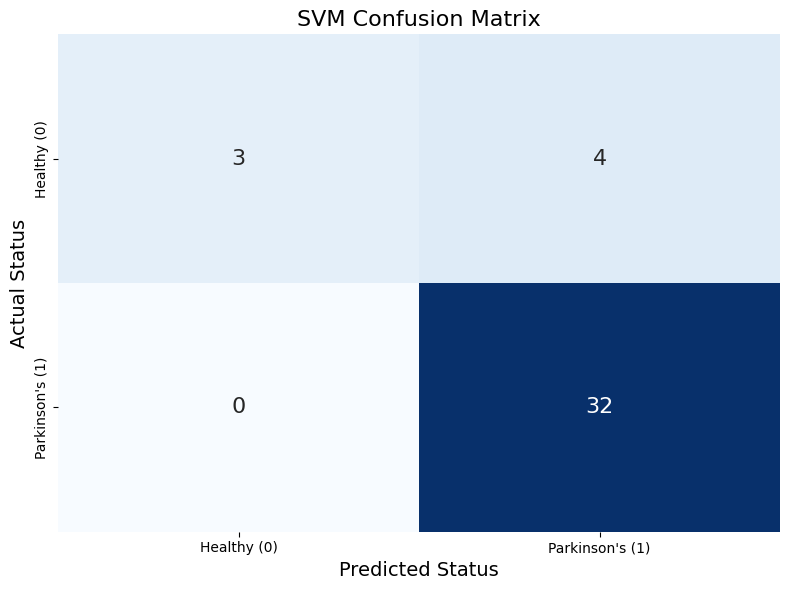

In [20]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Healthy (0)', 'Parkinson\'s (1)'], 
            yticklabels=['Healthy (0)', 'Parkinson\'s (1)'],
            annot_kws={"size": 16})
plt.title('SVM Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Status', fontsize=14)
plt.ylabel('Actual Status', fontsize=14)
plt.tight_layout()

The above matrix is called **Confusion Matrix**.

1. **Top-Left (3): True Negatives.** The model correctly identified 3 healthy patients!
2. **Top-Right (4): False Positives.** These are the 4 healthy patients the model accidentally flagged as having Parkinson's.
3. **Bottom-Left (0): False Negatives.** The model didn't miss a single Parkinson's patient! This is the most crucial box in medical AI.
4. **Bottom-Right (32): True Positives.** The model correctly identified 32 Parkinson's patients.

In [2]:
# Linear Regression to predict the status of Parkinson's disease based on the features in the dataset.
from sklearn.linear_model import LinearRegression

# Ensure data is scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
y_pred_binary = (y_pred >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred_binary):.4f}\n")
print(classification_report(y_test, y_pred_binary))
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, 
            xticklabels=['Healthy (0)', 'Parkinson\'s (1)'], 
            yticklabels=['Healthy (0)', 'Parkinson\'s (1)'],
            annot_kws={"size": 16})
plt.title('Linear Regression Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Status', fontsize=14)
plt.ylabel('Actual Status', fontsize=14)
plt.tight_layout()

NameError: name 'StandardScaler' is not defined